In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from difflib import get_close_matches
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold


# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [2]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [3]:
# Exclude compounds found in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [4]:

cleaned_sample_data=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_features_with_meta.csv")

# Step 1: Build sample_matching dictionary automatically
sample_matching = {}
for col in cleaned_sample_data.columns:
    match = re.search(r'S96_(\d+)_B1_D\d+_T1', col)
    if match:
        sample_num = match.group(1)
        filename = f'sample_{sample_num}.csv'
        sample_matching[filename] = col

# Manually add missing samples 46 and 47
sample_matching['sample_46.csv'] = 's179 S96_46_B1_D10_T2'
sample_matching['sample_47.csv'] = 's148 S96_47_B1_D8_T2'

print("Sample matching dictionary with added missing samples:")
print(sample_matching)

# Step 2: Define function to find closest peak by RT with tolerance
def find_closest_peak(rt, peaks_rt, tol=0.1):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()  # index of closest peak
    else:
        return None

# Step 3: Match compounds to intensities in cleaned_sample_data
matches = []
peaks_rt = cleaned_sample_data['tR_best']

for i, row in compound_df.iterrows():
    file_name = row['FileName']
    sample_col = sample_matching.get(file_name)
    if sample_col is None:
        # No matching sample column found for this compound
        continue
    
    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, peaks_rt)
    
    if peak_idx is None:
        # No peak found within tolerance for this compound RT
        continue
    
    intensity = cleaned_sample_data.loc[peak_idx, sample_col]
    
    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'Sample': sample_col,
        'Component RT': compound_rt,
        'Peak': cleaned_sample_data.loc[peak_idx, 'Peak'],
        'tR_best': cleaned_sample_data.loc[peak_idx, 'tR_best'],
        'm/z': cleaned_sample_data.loc[peak_idx, 'm/z'],
        'Intensity': intensity
    })

# Step 4: Create final matched DataFrame
compound_intesity_df = pd.DataFrame(matches)

print(f"Number of matched compound intensities: {compound_intesity_df .shape[0]}")
print(compound_intesity_df .head())
print(compound_intesity_df.shape)

Sample matching dictionary with added missing samples:
{'sample_10.csv': 's26 S96_10_B1_D2_T1', 'sample_11.csv': 's169 S96_11_B1_D10_T1', 'sample_12.csv': 's78 S96_12_B1_D5_T1', 'sample_13.csv': 's153 S96_13_B1_D9_T1', 'sample_14.csv': 's2 S96_14_B1_D1_T1', 'sample_15.csv': 's93 S96_15_B1_D6_T1', 'sample_16.csv': 's39 S96_16_B1_D3_T1', 'sample_17.csv': 's151 S96_17_B1_D9_T1', 'sample_18.csv': 's59 S96_18_B1_D4_T1', 'sample_19.csv': 's174 S96_19_B1_D10_T1', 'sample_1.csv': 's80 S96_1_B1_D5_T1', 'sample_20.csv': 's152 S96_20_B1_D9_T1', 'sample_21.csv': 's6 S96_21_B1_D1_T1', 'sample_22.csv': 's137 S96_22_B1_D8_T1', 'sample_23.csv': 's154 S96_23_B1_D9_T1', 'sample_24.csv': 's119 S96_24_B1_D7_T1', 'sample_25.csv': 's95 S96_25_B1_D6_T1', 'sample_26.csv': 's140 S96_26_B1_D8_T1', 'sample_27.csv': 's157 S96_27_B1_D9_T1', 'sample_28.csv': 's4 S96_28_B1_D1_T1', 'sample_29.csv': 's150 S96_29_B1_D9_T1', 'sample_2.csv': 's114 S96_2_B1_D7_T1', 'sample_30.csv': 's79 S96_30_B1_D5_T1', 'sample_31.csv': 

In [5]:
compound_intesity_df .to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_intensity.csv", index=False)
len(compound_intesity_df['Sample'].unique())

94

# Checking the presence of known potato aroma compounds

In [6]:
from difflib import get_close_matches

# Your list of potato aroma compounds
potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Normalize aroma list into dictionary: normalized name -> original name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched_df
compound_intesity_df['norm_name'] = compound_intesity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intesity_df['is_aroma'] =compound_intesity_df['norm_name'].isin(ref_norm)

# Fuzzy matching for compounds not exactly matched
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intesity_df['is_aroma']
fuzzy_hits = compound_intesity_df.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm.keys())))

# Mark fuzzy matched as aroma and update 'Compound Name' with official name
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Filter only aroma compounds
aroma_sample_df = compound_intesity_df[compound_intesity_df['is_aroma']].copy()

print(f"Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(aroma_sample_df.head())

len(aroma_sample_df['Sample'].unique())


Number of aroma compound records: 570
                   Compound Name      FileName              Sample  \
0             Butanal, 3-methyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
1                       Pentanal  sample_7.csv  s18 S96_7_B1_D1_T1   
3                        Hexanal  sample_7.csv  s18 S96_7_B1_D1_T1   
4  Cyclotrisiloxane, hexamethyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
5                   Benzaldehyde  sample_7.csv  s18 S96_7_B1_D1_T1   

   Component RT  Peak  tR_best  m/z  Intensity                   norm_name  \
0      2.899483    27    2.890   44  15.879306              butanal3methyl   
1      3.317483    41    3.375   81  19.455887                    pentanal   
3      5.282067    73    5.199  149  15.227984                     hexanal   
4      5.883333    80    5.903  207  17.026906  cyclotrisiloxanehexamethyl   
5      9.314117   145    9.347  267  17.161132                benzaldehyde   

   is_aroma  
0      True  
1      True  
3      True  
4      True  
5 

94

In [7]:
# Unique varieties before aroma assignment
varieties_before = set(compound_intesity_df['Sample'].unique())
print(f"Number of varieties before aroma assignment: {len(varieties_before)}")

# Unique varieties after aroma assignment (assuming aroma-assigned dataframe is aroma_per_variety or similar)
varieties_after = set(aroma_sample_df['Sample'].unique())
print(f"Number of varieties after aroma assignment: {len(varieties_after)}")

# Varieties missing aroma assignment
missing_varieties = varieties_before - varieties_after
print(f"Varieties missing aroma info: {missing_varieties}")


Number of varieties before aroma assignment: 94
Number of varieties after aroma assignment: 94
Varieties missing aroma info: set()


In [8]:
missing_samples = ['s59 S96_18_B1_D4_T1', 's3 S96_9_B1_D1_T1', 's120 S96_90_B1_D7_T1', 's133 S96_54_B1_D8_T1']

missing_data = compound_intesity_df[compound_intesity_df['Sample'].isin(missing_samples)]
print(missing_data[['Sample', 'Compound Name', 'is_aroma']].head(20))

# How many aroma compounds (is_aroma=True) are in these samples?
print(missing_data.groupby('Sample')['is_aroma'].sum())


                  Sample                            Compound Name  is_aroma
16     s3 S96_9_B1_D1_T1                       Butanal, 3-methyl-      True
17     s3 S96_9_B1_D1_T1                      Disulfide, dimethyl     False
18     s3 S96_9_B1_D1_T1                                  Hexanal      True
19     s3 S96_9_B1_D1_T1            Cyclotrisiloxane, hexamethyl-      True
20     s3 S96_9_B1_D1_T1                             Benzaldehyde      True
21     s3 S96_9_B1_D1_T1                      Dimethyl trisulfide      True
22     s3 S96_9_B1_D1_T1                                  Octanal      True
23     s3 S96_9_B1_D1_T1                      1-Hexanol, 2-ethyl-     False
24     s3 S96_9_B1_D1_T1                                 Dodecane     False
25     s3 S96_9_B1_D1_T1                                  Decanal      True
26     s3 S96_9_B1_D1_T1                                Tridecane     False
27     s3 S96_9_B1_D1_T1                              Tetradecane     False
28     s3 S9

# Map variety on samples

In [9]:

# Load master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber from your aroma_samples 'FileName' (assumes sample_##.csv format)
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filter master table to exclude blanks/QC etc.
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

# Extract SampleNumber from master 'Filename' column, e.g. "_12_B" => 12
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare mapping table: SampleNumber -> Variety (remove duplicates)
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column (if you don't need it)
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])

# Now print without the FileName column
print(aroma_per_variety)



                     Compound Name                 Sample  Component RT  Peak  \
0               Butanal, 3-methyl-     s18 S96_7_B1_D1_T1      2.899483    27   
1                         Pentanal     s18 S96_7_B1_D1_T1      3.317483    41   
2                          Hexanal     s18 S96_7_B1_D1_T1      5.282067    73   
3    Cyclotrisiloxane, hexamethyl-     s18 S96_7_B1_D1_T1      5.883333    80   
4                     Benzaldehyde     s18 S96_7_B1_D1_T1      9.314117   145   
..                             ...                    ...           ...   ...   
565  Cyclotrisiloxane, hexamethyl-  s171 S96_89_B1_D10_T1      5.886600    80   
566                   Benzaldehyde  s171 S96_89_B1_D10_T1      9.333467   145   
567  Cyclotrisiloxane, hexamethyl-  s173 S96_91_B1_D10_T1      5.886867    80   
568                   Benzaldehyde  s173 S96_91_B1_D10_T1      9.334584   145   
569                        Decanal  s173 S96_91_B1_D10_T1     13.722683   274   

     tR_best  m/z  Intensit

# Full dataframe including the varairty, aroma compounds and their description.

In [10]:
aroma_descriptions = {
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "Benzaldehyde": "Almond, cherry, fruity",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Furfural": "Sweet, almond, caramel",
    "Methional": "Cooked potato, sulfurous",
    "Octanal": "Citrus, fruity",
    "Decanal": "Citrus, floral",
    "Hexanoic acid": "Fatty, cheesy, sweaty",
    "2,3-Butanedione": "Butter, creamy, sweet",
    "2-Acetylpyrazine": "Nutty, roasted",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "3-Octanone": "Mushroom, earthy",
    "1-Phenylethanol": "Floral, rose",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate",
    "1-Octen-3-ol": "Mushroom, earthy",
    "Dimethyl disulfide": "Garlic, onion",
    "Ethyl 2-methylbutanoate": "Fruity, apple",
}


aroma_per_variety['Aroma Description'] = aroma_per_variety['Compound Name'].map(aroma_descriptions)
print(aroma_per_variety.head(20))


                    Compound Name              Sample  Component RT  Peak  \
0              Butanal, 3-methyl-  s18 S96_7_B1_D1_T1      2.899483    27   
1                        Pentanal  s18 S96_7_B1_D1_T1      3.317483    41   
2                         Hexanal  s18 S96_7_B1_D1_T1      5.282067    73   
3   Cyclotrisiloxane, hexamethyl-  s18 S96_7_B1_D1_T1      5.883333    80   
4                    Benzaldehyde  s18 S96_7_B1_D1_T1      9.314117   145   
5             Dimethyl trisulfide  s18 S96_7_B1_D1_T1      9.519900   149   
6                         Octanal  s18 S96_7_B1_D1_T1     10.191900   172   
7                         Decanal  s18 S96_7_B1_D1_T1     13.703067   274   
8              Butanal, 3-methyl-   s3 S96_9_B1_D1_T1      2.899650    27   
9                         Hexanal   s3 S96_9_B1_D1_T1      5.282233    73   
10  Cyclotrisiloxane, hexamethyl-   s3 S96_9_B1_D1_T1      5.886717    80   
11                   Benzaldehyde   s3 S96_9_B1_D1_T1      9.314283   145   

# aroma intensities per variety

In [11]:
aroma_pivot = aroma_per_variety.pivot_table(index='Variety', columns='Compound Name', values='Intensity', aggfunc='mean').fillna(0)

print(aroma_pivot.head())

Compound Name  1-Nonanol  2,3-Butanedione  Benzaldehyde  Butanal, 3-methyl-  \
Variety                                                                       
ADORA                0.0              0.0     17.984870           15.836435   
AGRIA                0.0              0.0     14.859493           14.154847   
ALOUETTE             0.0              0.0     15.205705           15.262178   
ALTHEA               0.0              0.0     19.535081           14.984406   
ALTURAS              0.0              0.0     20.293776           14.482897   

Compound Name  Cyclotrisiloxane, hexamethyl-    Decanal  Dimethyl trisulfide  \
Variety                                                                        
ADORA                              17.417208  18.203338              0.00000   
AGRIA                              15.947810  14.499810             17.21077   
ALOUETTE                           14.678352  17.462371              0.00000   
ALTHEA                             17.704453  

In [12]:

# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]

print(aroma_pivot_renamed.head())


    Variety  1-Nonanol (Floral, waxy)  \
0     ADORA                       0.0   
1     AGRIA                       0.0   
2  ALOUETTE                       0.0   
3    ALTHEA                       0.0   
4   ALTURAS                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.205705   
3                              19.535081   
4                              20.293776   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                                      15.262178   
3  

 PCA on aroma intensities

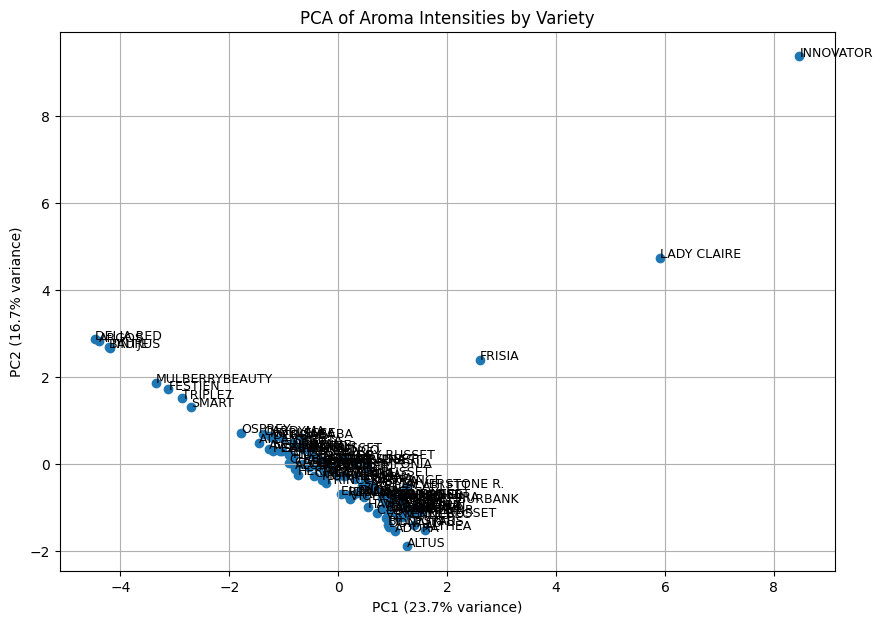

In [13]:

# If 'Variety' is a column, set it as index:
if 'Variety' in aroma_pivot_renamed.columns:
    aroma_pivot_renamed.set_index('Variety', inplace=True)

# Now extract numeric data (no strings)
X_numeric = aroma_pivot_renamed.values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Use the index (varieties) for labels
for i, variety in enumerate(aroma_pivot_renamed.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], variety, fontsize=9)

plt.xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of Aroma Intensities by Variety')
plt.grid(True)
plt.show()

 INNOVATOR and LADY CLAIRE stand out as different from most others.

#  Statistics of aroma intensities per variety

In [14]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.head(5)

Top 10 aroma compounds by average intensity:
                                                         mean       std
Benzaldehyde (Almond, cherry, fruity)               16.398647  1.750228
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  15.984822  1.582331
Decanal (Citrus, floral)                            14.820036  3.814669
Octanal (Citrus, fruity)                            13.156437  7.159785
Butanal, 3-methyl- (Fruity, malty, chocolate)       12.223914  6.220205
Dimethyl trisulfide (Garlic, onion, sulfurous)       8.927816  9.188503
Hexanal (Green, grassy)                              6.538783  7.387660
Pentanal (Green, fatty, pungent)                     3.201202  7.406310
Hexanoic acid (Fatty, cheesy, sweaty)                3.034014  7.384243
Furfural (Sweet, almond, caramel)                    0.443991  2.460374


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
Variety,,,,,,,,,,,,,
ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


Benzaldehyde and Cyclotrisiloxane, hexamethyl- these aromas are generally strong across many varieties

# Cluster Analysis

Number of unique varieties: 94
Some varieties: ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANIVIA', 'ANTI', 'ARDECHE']


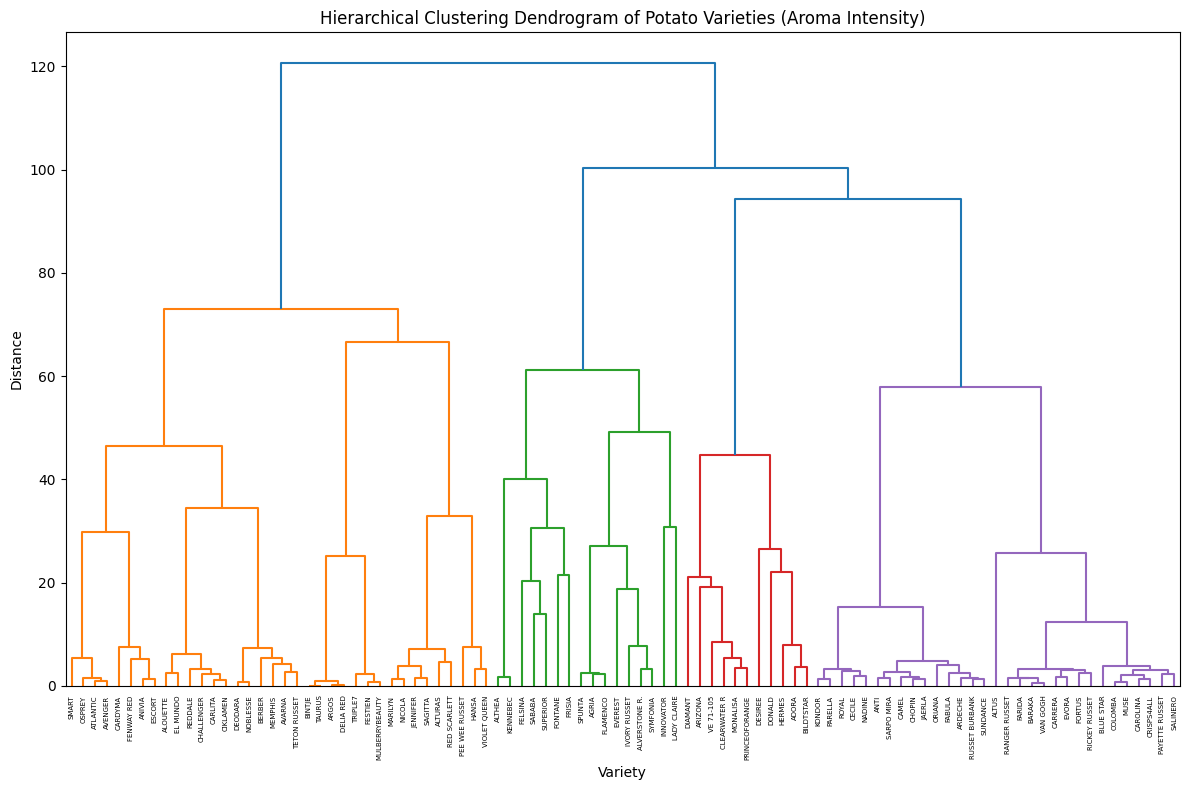

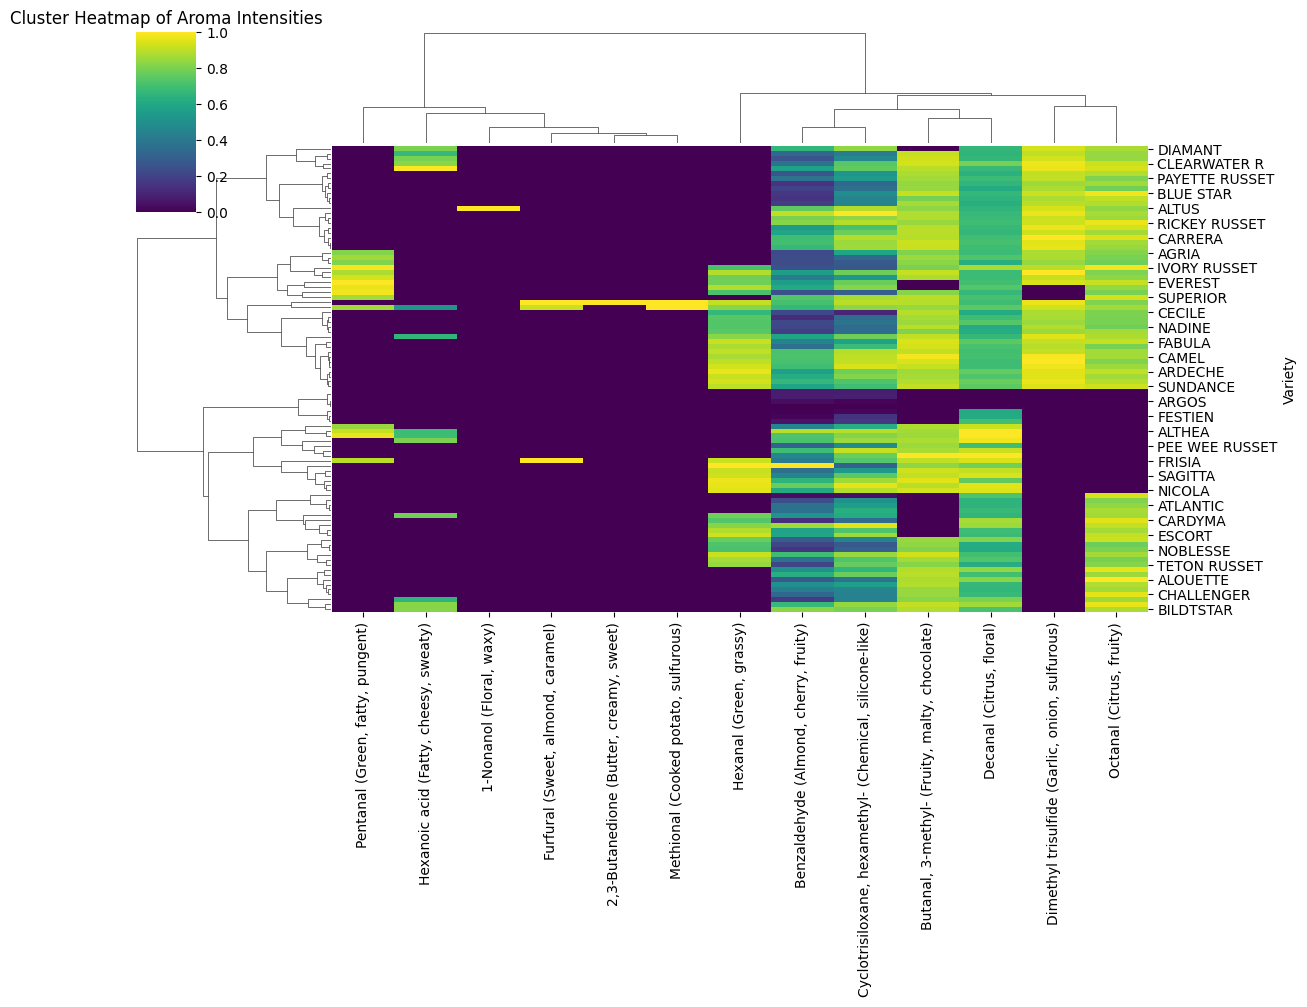

In [15]:
# Number of unique varieties (index labels)
num_varieties = aroma_pivot_renamed.index.nunique()
print(f"Number of unique varieties: {num_varieties}")

# Optionally, see the first few variety names
print("Some varieties:", aroma_pivot_renamed.index[:10].tolist())

# Compute linkage matrix for hierarchical clustering (using Ward's method)
Z = linkage(aroma_pivot_renamed, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=aroma_pivot_renamed.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Potato Varieties (Aroma Intensity)')
plt.xlabel('Variety')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Optional: Cluster heatmap (combines dendrogram + heatmap)
sns.clustermap(aroma_pivot_renamed, method='ward', figsize=(12, 10), cmap='viridis', standard_scale=1)
plt.title('Cluster Heatmap of Aroma Intensities')
plt.show()


dendrogram shows how potato varieties cluster based on aroma intensities.
varieties like DIAMANT, CLEARWATER R, PAYETTE RUSSET, BLUE STAR form a cluster, indicating they share similar aroma compound intensities.

Another cluster around AVARNA, REEDDALE, CARLITA, HERMES also suggests similarity in their aroma profiles.

DIAMANT has high intensity for Pentanal but low for compounds like Dimethyl trisulfide
ALTUS and RICKY RUSSET show more balanced intensities with less extreme values

In [16]:
from scipy.spatial.distance import pdist, squareform
# Step 1: Calculate distance matrix (Euclidean distance)
dist_matrix = pd.DataFrame(
    squareform(pdist(aroma_pivot_renamed, metric='euclidean')),
    index=aroma_pivot_renamed.index,
    columns=aroma_pivot_renamed.index
)

# Step 2: Melt to long format to get pairs with distances
# Temporarily remove index/column names to avoid conflict
dist_matrix.index.name = None
dist_matrix.columns.name = None

# Mask diagonal to remove self-distance
dist_masked = dist_matrix.where(~np.eye(dist_matrix.shape[0], dtype=bool))

# Stack and reset index (index names will default to 0 and 1, avoiding conflicts)
dist_pairs = dist_masked.stack().reset_index()
dist_pairs.columns = ['Variety1', 'Variety2', 'Distance']

# Step 3: Sort by distance to get most similar and most different pairs
most_similar = dist_pairs.nsmallest(5, 'Distance')
most_different = dist_pairs.nlargest(5, 'Distance')

print("Top 5 most similar varieties (smallest distance):")
print(most_similar)

print("\nTop 5 most different varieties (largest distance):")
print(most_different)


Top 5 most similar varieties (smallest distance):
       Variety1   Variety2  Distance
1761     BINTJE     TAURUS  0.066150
8202     TAURUS     BINTJE  0.066150
961       ARGOS  DELIA RED  0.232420
2986  DELIA RED      ARGOS  0.232420
947       ARGOS     BINTJE  0.513634

Top 5 most different varieties (largest distance):
       Variety1     Variety2   Distance
4891  INNOVATOR     KENNEBEC  50.540386
5260   KENNEBEC    INNOVATOR  50.540386
330      ALTHEA    INNOVATOR  50.035902
4839  INNOVATOR       ALTHEA  50.035902
3033  DELIA RED  LADY CLAIRE  48.449229


# joining the sensory panel data 

In [17]:
sensory = pd.read_excel(r"C:\Users\fatemehm\Downloads\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [18]:

# Clean the VARIETY column (strip spaces) and keep it as a column
sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# Select the flavor-related columns (assuming flavor columns are from column 3 to 46, zero-based)
sensory_traits = sensory.iloc[:, 3:47].apply(pd.to_numeric, errors='coerce')

# Drop unnamed columns if any (just in case)
sensory_traits = sensory_traits.drop(columns=[c for c in sensory_traits.columns if "Unnamed" in str(c)], errors='ignore')

# Add the VARIETY column back to the dataframe for comparison
sensory_traits['VARIETY'] = sensory['VARIETY']

# Group by VARIETY to get mean values per variety, ignoring NaNs
sensory_summary = sensory_traits.groupby('VARIETY').mean().reset_index()

# Now you have a dataframe with 'VARIETY' as a column and the mean sensory traits for each variety
print(sensory_summary.head())
len(sensory_summary['VARIETY'].unique())

  VARIETY  Intensity of Skin Colour  Thickness of skin  Speckles/Blemishes  \
0   ADORA                    47.229             23.958              44.438   
1   AGATA                    30.604             18.896              41.417   
2   AGRIA                    61.187             33.875              32.333   
3   AMBRA                    43.667             21.354              28.458   
4  AMPERA                    61.604             24.938              28.875   

   Wrinkles  Dryness  Skin Separation  Colour  Visible Ring  \
0    12.667   40.521           20.188  20.708        13.333   
1    13.125   33.500           25.229  37.167        15.167   
2    10.229   50.979           29.708  64.583        25.792   
3    10.333   36.729           20.479  53.417        23.542   
4    14.396   45.396           19.417  67.271         8.500   

   Patches/ Blemishes  ...  Sticky - Flesh  Soft - Flesh  Chewy - Skin  \
0               5.521  ...          28.364        40.155        30.056   
1   

59

In [19]:
# List of keywords indicating flavor-related columns
flavor_keywords = ['flavour' , 'sweet', 'sour', 'bitter', 'salty', 'umami','metallic']

# Find flavor-related columns (case insensitive)
flavor_cols = [col for col in sensory.columns if any(keyword in col.lower() for keyword in flavor_keywords)]

# Include 'VARIETY' column for grouping/comparison
flavor_cols = ['VARIETY'] + flavor_cols

# Extract these columns
sensory_flavors = sensory[flavor_cols].copy()

# Convert all flavor columns to numeric, in case of strings
for col in flavor_cols[1:]:  # skip VARIETY
    sensory_flavors[col] = pd.to_numeric(sensory_flavors[col], errors='coerce')

# Group by VARIETY and average duplicates
sensory_flavors_summary = sensory_flavors.groupby('VARIETY').mean().reset_index()

print(sensory_flavors_summary.head())
len(sensory_flavors_summary['VARIETY'].unique())

  VARIETY  Sweet  Intensity of Flavour  Metallic Flavour  Bitter Flavour  \
0   ADORA  4.385                40.979            17.627          15.329   
1   AGATA  5.537                42.109            10.171          11.633   
2   AGRIA  3.298                35.348             8.018           5.872   
3   AMBRA  4.755                41.457            11.192          12.155   
4  AMPERA  4.407                39.022            13.018          11.176   

   Earthy Flavour  Sour Flavour  Fresh Flavour  Sweet Flavour  \
0          26.573        10.678         24.014          3.098   
1          18.378         7.548         30.340          3.250   
2          20.421         3.787         29.188          1.859   
3          20.334         7.135         33.122          2.729   
4          20.486        11.591         24.644          3.511   

   Root/ Vegetable Flavour  Farmyard (grass/hay) flavour  Bitter Aftertaste  \
0                   17.360                        12.520             15.6

59

In [20]:
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.rename(columns={'index': 'Variety'}, inplace=True)
sensory_flavors_summary.rename(columns={'VARIETY': 'Variety'}, inplace=True)

# Now both dataframes have 'Variety' column

# Clean whitespace and case
for df in [aroma_df, sensory_flavors_summary]:
    df['Variety'] = df['Variety'].astype(str).str.strip().str.upper()

# Merge on 'Variety'
merged_aroma_sensory = pd.merge(aroma_df, sensory_flavors_summary, on='Variety', how='inner')

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())

merged_aroma_sensory.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\merged_aroma_sensory.csv', index=False)


Number of merged varieties: 20
     Variety  1-Nonanol (Floral, waxy)  \
0      ADORA                       0.0   
1      AGRIA                       0.0   
2     BERBER                       0.0   
3  BILDTSTAR                       0.0   
4     BINTJE                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.354625   
3                              19.062354   
4                              13.831978   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                 

# using Random forest regressor for predcting the flavors for varaiety tthat not exist in sensory panel

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# aroma features (exclude 'Variety')
X = merged_aroma_sensory[aroma_df.columns.drop('Variety')]

# target flavor columns from sensory data (e.g., 'Sweet', 'Bitter Flavour', etc.)
flavor_cols = sensory_flavors_summary.columns.drop('Variety')
y = merged_aroma_sensory[flavor_cols]

# Select rows with complete sensory data (no missing)
train_idx = y.dropna().index

X_train = X.loc[train_idx]
y_train = y.loc[train_idx]

# Select rows with missing sensory data (to predict)
predict_idx = y[y.isna().any(axis=1)].index
X_predict = X.loc[predict_idx]

# Dictionary to hold models and predictions
flavor_models = {}
predicted_flavors = pd.DataFrame(index=predict_idx, columns=flavor_cols)

# Train and predict each flavor separately
for flavor in flavor_cols:
    # Drop rows with NaN for current flavor
    train_rows = y_train[flavor].dropna().index
    X_train_flavor = X_train.loc[train_rows]
    y_train_flavor = y_train.loc[train_rows, flavor]
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_flavor, y_train_flavor)
    flavor_models[flavor] = model
    
    # Cross-validation score
    scores = cross_val_score(model, X_train_flavor, y_train_flavor, cv=5, scoring='r2')
    print(f"{flavor} CV R^2: {np.mean(scores):.3f} ± {np.std(scores):.3f}")
    
    # Predict missing
    if not X_predict.empty:
        predicted_flavors.loc[:, flavor] = model.predict(X_predict)

# Now you can fill your merged_df sensory flavor columns with predicted values for missing
for flavor in flavor_cols:
    merged_aroma_sensory.loc[predict_idx, flavor] = predicted_flavors.loc[:, flavor]

# merged_df now contains both measured and predicted flavor values for all aroma varieties


Sweet CV R^2: -3.651 ± 7.209
Intensity of Flavour CV R^2: -1.083 ± 1.357
Metallic Flavour CV R^2: -2.328 ± 2.929
Bitter Flavour CV R^2: -0.414 ± 0.764
Earthy Flavour CV R^2: -2.310 ± 2.848
Sour Flavour CV R^2: -0.606 ± 0.557
Fresh Flavour CV R^2: -3.421 ± 3.230
Sweet Flavour CV R^2: -1.802 ± 3.232
Root/ Vegetable Flavour CV R^2: -0.978 ± 1.298
Farmyard (grass/hay) flavour CV R^2: -0.140 ± 0.826
Bitter Aftertaste CV R^2: -0.726 ± 0.823
Sour Aftertaste CV R^2: -0.326 ± 0.310
Sweet Aftertaste CV R^2: -1.055 ± 1.352


Select features and targets

Fit PLSRegression instead of random forest regressor and evaluate with cross-validation

In [22]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

X = merged_aroma_sensory[aroma_df.columns.difference(['Variety'])].values
flavor_cols = [col for col in flavor_cols if col != 'Variety']

for flavor in flavor_cols:
    y_flavor = merged_aroma_sensory[flavor].values
    mask = ~np.isnan(y_flavor)
    X_flavor = X[mask]
    y_flavor = y_flavor[mask]
    
    print(f"{flavor}: samples={len(y_flavor)}, mean={np.mean(y_flavor):.3f}, std={np.std(y_flavor):.3f}")
    
    if len(y_flavor) < 10 or np.std(y_flavor) < 1e-5:
        print(f"Skipping {flavor} due to too few samples or low variance.")
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flavor)
    
    pca = PCA(n_components=min(3, X_scaled.shape[1]))
    X_pca = pca.fit_transform(X_scaled)
    
    pls = PLSRegression(n_components=1)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(pls, X_pca, y_flavor, cv=cv, scoring='r2')
    
    print(f"{flavor} CV R^2: {scores.mean():.3f} ± {scores.std():.3f}")


Sweet: samples=20, mean=4.693, std=2.120
Sweet CV R^2: -0.669 ± 0.610
Intensity of Flavour: samples=20, mean=39.329, std=2.857
Intensity of Flavour CV R^2: -0.760 ± 0.754
Metallic Flavour: samples=20, mean=8.831, std=2.826
Metallic Flavour CV R^2: -0.337 ± 0.728
Bitter Flavour: samples=20, mean=7.628, std=2.354
Bitter Flavour CV R^2: -0.427 ± 0.355
Earthy Flavour: samples=20, mean=17.623, std=3.613
Earthy Flavour CV R^2: -0.985 ± 1.829
Sour Flavour: samples=20, mean=6.359, std=1.958
Sour Flavour CV R^2: -0.642 ± 0.648
Fresh Flavour: samples=20, mean=30.203, std=5.053
Fresh Flavour CV R^2: -0.522 ± 0.563
Sweet Flavour: samples=20, mean=4.275, std=1.952
Sweet Flavour CV R^2: -1.127 ± 1.816
Root/ Vegetable Flavour: samples=20, mean=12.677, std=2.165
Root/ Vegetable Flavour CV R^2: -1.126 ± 1.400
Farmyard (grass/hay) flavour: samples=20, mean=7.750, std=2.621
Farmyard (grass/hay) flavour CV R^2: -1.699 ± 2.799
Bitter Aftertaste: samples=20, mean=7.772, std=2.319
Bitter Aftertaste CV R^2: -

put zero for flavor of other varaities

In [23]:

# Reset index and rename columns if not done already
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.rename(columns={'index': 'Variety'}, inplace=True)
sensory_flavors_summary.rename(columns={'VARIETY': 'Variety'}, inplace=True)

# Clean whitespace and case for consistent merging
for df in [aroma_df, sensory_flavors_summary]:
    df['Variety'] = df['Variety'].astype(str).str.strip().str.upper()

# Perform left join to keep all aroma varieties
merged_aroma_sensory = pd.merge(aroma_df, sensory_flavors_summary, on='Variety', how='left')

# Fill NaNs in sensory flavor columns with 0
# Identify sensory flavor columns by excluding 'Variety' and aroma columns
# Assuming sensory columns are those originally in sensory_flavors_summary except 'Variety'
sensory_cols = [col for col in sensory_flavors_summary.columns if col != 'Variety']

merged_aroma_sensory[sensory_cols] = merged_aroma_sensory[sensory_cols].fillna(0)

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())

merged_aroma_sensory.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\merged_aroma_sensory.csv', index=False)


Number of merged varieties: 94
    Variety  1-Nonanol (Floral, waxy)  \
0     ADORA                       0.0   
1     AGRIA                       0.0   
2  ALOUETTE                       0.0   
3    ALTHEA                       0.0   
4   ALTURAS                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.205705   
3                              19.535081   
4                              20.293776   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                       